In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import tqdm
from copy import deepcopy

In [565]:
rng = np.random.default_rng(829)

In [566]:
metrics = [
    "mean_1_point",
    "mean_2_point",
    "vars_1_point",
    "vars_2_point",
    "prsn_point",
    "sprm_point"
]

In [7]:
# global settings
global_settings = {
    'cells': 10000,
    'genes': 2,
    'repeats': 30
}

In [590]:
def compute_data_statistics(data_name):

    # load counts
    counts = np.load(f"./data/{data_name}.npy")

    # result dataframe
    result_df = pd.DataFrame(
        index=list(range(global_settings['repeats'])),
        columns=metrics
    )

    for i in range(global_settings['repeats']):

        mean = np.mean(counts[:, :, i], axis=0)
        var = np.var(counts[:, :, i], axis=0)
        prsn = scipy.stats.pearsonr(counts[:, 0, i], counts[:, 1, i]).statistic
        sprm = scipy.stats.spearmanr(counts[:, 0, i], counts[:, 1, i]).statistic

        result_df.loc[i, :] = [
            float(mean[0]),
            float(mean[1]),
            float(var[0]),
            float(var[1]),
            float(prsn),
            float(sprm)
        ]

    # store
    result_df.to_csv(f"./data/{data_name}.csv", index=False)

    return result_df

# Real data

## Parameter calibration

In [2]:
import scanpy as sc
import anndata as ad

In [569]:
def sparse_corrcoef(A):

    A = scipy.sparse.csr_matrix(A)

    # tranpose to make genes rows
    A = A.T

    A = A.astype(np.float64)
    n = A.shape[1]

    # Compute the covariance matrix
    rowsum = A.sum(1)
    centering = rowsum.dot(rowsum.T.conjugate()) / n
    C = (A.dot(A.T.conjugate()) - centering) / (n - 1)

    # The correlation coefficients are given by
    # C_{i,j} / sqrt(C_{i} * C_{j})
    d = np.diag(C)
    coeffs = C / np.sqrt(np.outer(d, d))
    # coeffs = C

    return np.array(coeffs)

In [570]:
# load dataset
adata_real = ad.read_h5ad("../data/hca_subsampled_20k.h5ad")

# filter low expression genes
sc.pp.filter_genes(adata_real, min_counts=3)

# set layer
adata_real.layers["counts"] = adata_real.X.copy()

# feature selection of highly variable genes
sc.pp.highly_variable_genes(
    adata_real,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source",
)

# subset cells
adata_real = adata_real[:global_settings['cells'], :]

In [571]:
# compute observed means
observed_mean = np.array(adata_real.layers['counts'].mean(axis=0)).squeeze()

# compute observed vars
observed_vars = np.array(adata_real.layers['counts'].power(2).mean(axis=0)).squeeze() - observed_mean**2

# compute observed correlations
observed_corr = sparse_corrcoef(adata_real.layers['counts'])[np.triu_indices(adata_real.n_vars, k=1)]

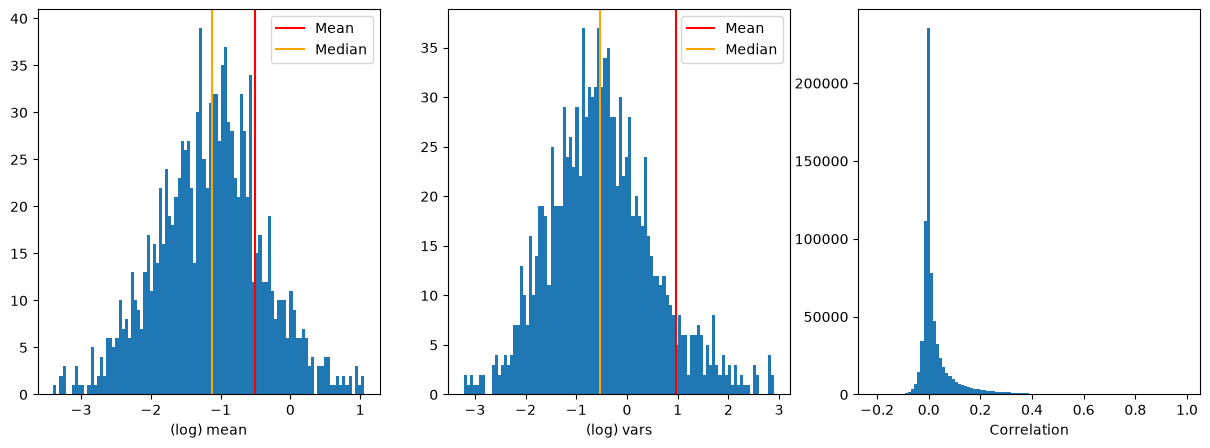

In [572]:
mean_mean = np.mean(observed_mean)
mean_median = np.median(observed_mean)
vars_mean = np.mean(observed_vars)
vars_median = np.median(observed_vars)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].hist(np.log10(observed_mean), bins=100)
axs[0].axvline(np.log10(mean_mean), color="red", label="Mean")
axs[0].axvline(np.log10(mean_median), color="orange", label="Median")
axs[0].set_xlabel("(log) mean")
axs[0].legend()
axs[1].hist(np.log10(observed_vars), bins=100)
axs[1].axvline(np.log10(vars_mean), color="red", label="Mean")
axs[1].axvline(np.log10(vars_median), color="orange", label="Median")
axs[1].set_xlabel("(log) vars")
axs[1].legend()
axs[2].hist(observed_corr, bins=100)
axs[2].set_xlabel("Correlation")
plt.show()

In [601]:
# mean
10 ** -1, 10 ** -0.5

(0.1, 0.31622776601683794)

In [602]:
# var
10** - 0.5, 10 ** 1

(0.31622776601683794, 10)

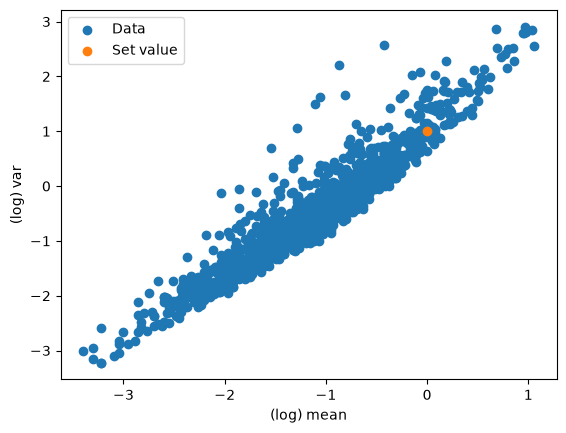

In [1090]:
m = 1
v = 10
plt.scatter(np.log10(observed_mean), np.log10(observed_vars), label="Data")
plt.scatter([np.log10(m)], [np.log10(v)], label="Set value")
plt.xlabel("(log) mean")
plt.ylabel("(log) var")
plt.legend()
plt.show()

## Heart cell atlas

In [573]:
# load dataset
adata_real = ad.read_h5ad("../data/hca_subsampled_20k.h5ad")

# filter low expression genes
sc.pp.filter_genes(adata_real, min_counts=3)

# set layer
adata_real.layers["counts"] = adata_real.X.copy()

# feature selection of highly variable genes
sc.pp.highly_variable_genes(
    adata_real,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source",
)

# subset cells
adata_real = adata_real[:global_settings['cells'], :]

In [574]:
# compute correlation matrix
Sigma = sparse_corrcoef(adata_real.X)

# set lower triangle to nan
Sigma_lower = deepcopy(Sigma)
Sigma_lower[np.tril_indices(Sigma.shape[0], k=0)] = np.nan

# collect indices of correlation values in the bins
bin_ends = [-0.4, 0.1, 0.3, 0.5, 0.7, 1]
bin_indices = [[] for _ in range(len(bin_ends) - 1)]

for i in range(len(bin_ends) - 1):
    bin_start = bin_ends[i]
    bin_end = bin_ends[i + 1]
    indices = np.argwhere((Sigma_lower > bin_start) & (Sigma_lower <= bin_end))
    bin_indices[i] = indices
    print(f"Bin ({bin_start}, {bin_end}]: {len(indices)}")

Bin (-0.4, 0.1]: 644531
Bin (0.1, 0.3]: 61163
Bin (0.3, 0.5]: 11525
Bin (0.5, 0.7]: 1976
Bin (0.7, 1]: 205


In [575]:
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

for i in range(global_settings['repeats']):

    # sample bin
    sampled_bin = rng.choice(len(bin_indices), size=1)[0]

    # sample gene pair from bin
    sampled_pair_index = rng.choice(len(bin_indices[sampled_bin]), size=1)[0]
    sampled_gene_pair = bin_indices[sampled_bin][sampled_pair_index]

    # select
    adata_sampled = adata_real[:, sampled_gene_pair]

    # store
    counts[:, :, i] = adata_sampled.X.toarray()

In [ ]:
# save
#np.save("./data/real-data.npy", counts)

In [1127]:
result_df = compute_data_statistics("real-data")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,0.168,0.05,3.489576,0.2943,0.880303,0.372571
1,0.0782,0.0568,0.408685,0.209574,0.32105,0.366643
2,2.0322,0.247,18.330363,1.419191,0.335687,0.382791
3,0.0744,0.0521,0.612465,0.166786,0.301067,0.350496
4,0.0331,0.0652,0.090804,0.188349,0.085197,0.043377
5,1.5026,0.9955,77.897393,55.50848,0.815501,0.452305
6,9.5226,6.9945,643.304089,331.69627,0.943463,0.735484
7,0.0115,9.5226,0.017968,643.304089,0.127298,0.047197
8,6.9945,9.1523,331.69627,631.321905,0.950234,0.741185
9,0.0959,0.2071,2.358703,4.32781,0.30574,0.390039


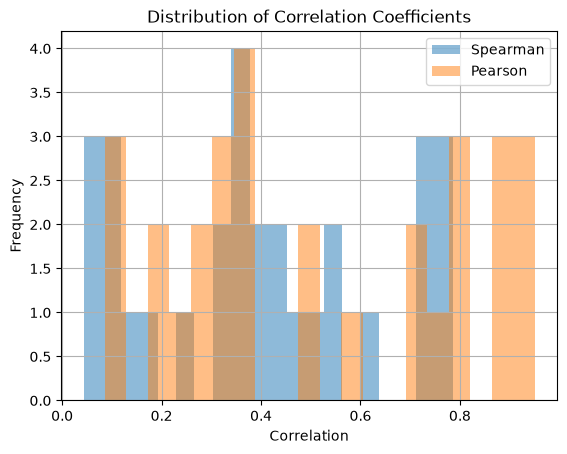

In [1128]:
result_df['sprm_point'].hist(bins=20, alpha=0.5, label='Spearman')
result_df['prsn_point'].hist(bins=20, alpha=0.5, label='Pearson')
plt.legend()
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Coefficients')
plt.show()

In [ ]:
# raw sampling: produces mostly uncorrelated gene pairs

'''
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

for i in range(global_settings['repeats']):

    # sample cells
    sampled_cells = rng.choice(adata_real.n_obs, size=global_settings['cells'], replace=False)

    # sample genes
    sampled_genes = rng.choice(adata_real.n_vars, size=global_settings['genes'], replace=False)

    # select
    adata_sampled = adata_real[sampled_cells, sampled_genes]

    # store
    counts[:, :, i] = adata_sampled.X.toarray()
'''

## Total cell counts

In [10]:
# load dataset
adata_real = ad.read_h5ad("../scVI-Investigation/data/hca_subsampled_20k.h5ad")

# subset cells
adata_real = adata_real[:global_settings['cells'], :]

# compute total cell counts over all genes
total_counts = np.array(adata_real.X.sum(axis=1)).squeeze()

In [ ]:
# save
#np.save("./data/total-counts.npy", total_counts)

In [14]:
np.load("./data/total-counts.npy")

array([1420.,  844., 1491., ...,  754., 1786., 2399.],
      shape=(10000,), dtype=float32)

# Simulated data

## Log-Normal mean

In [883]:
m = 1
v = 10

s = np.log((v - m + m**2) / m**2)
b = np.log(m) - (1 / 2) * s

print(s, b)

2.302585092994046 -1.151292546497023


(np.float64(1.015), np.float64(6.930775))

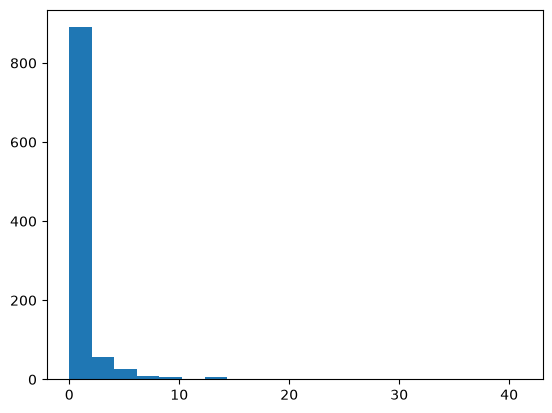

In [893]:
s = 2.3
b = -1.2

z = rng.normal(size=1000)
lam = np.exp(b + z * np.sqrt(s))
x = rng.poisson(lam)

plt.hist(x, bins=20);
np.mean(x), np.var(x)

In [966]:
mu = 1
theta = 2

print(mu), print(mu + mu / theta)

r = theta
var = mu + 1 / r * mu ** 2
p = (var - mu) / var

x = rng.negative_binomial(r, 1 - p, size=1000)

np.mean(x), np.var(x)

1
1.5


(np.float64(1.011), np.float64(1.410879))

In [1000]:
mu = 1
theta = 2

print(mu), print(mu + mu / theta)

r = theta
p = theta / (theta + mu)

x = rng.negative_binomial(r, p, size=1000)

np.mean(x), np.var(x)

1
1.5


(np.float64(1.018), np.float64(1.4096760000000002))

### NB

In [1069]:
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

# fix structural parameters
s = 1.5
b = -1 * np.ones((global_settings['genes']))
theta = 0.75

for i in range(global_settings['repeats']):

    # sample correlation
    p = rng.choice([-0.2, 0.2, 0.4, 0.6, 0.8])

    # construct parameters
    Sigma = np.array(([
        [1, p],
        [p, 1]
    ]))
    A = s * np.linalg.cholesky(Sigma)

    # sample mean
    z = rng.normal(size=(global_settings['cells'], global_settings['genes']))
    mu = np.exp(z @ A.T + b)

    # convert NB parametrization (mean, dispersion) -> (#successes, p(success))
    r = theta
    p = theta / (theta + mu)
    
    # sample counts
    counts[:, :, i] = rng.negative_binomial(r, p).astype(np.int32)

In [ ]:
# save
#np.save("./data/lognormal-nb.npy", counts)

In [1129]:
result_df = compute_data_statistics("lognormal-nb")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,1.1452,1.2127,25.903917,30.643459,0.237338,0.259909
1,1.0941,1.1376,17.963445,29.736066,0.038774,0.109245
2,1.1515,1.1801,33.426348,42.144064,0.506238,0.238128
3,1.1544,1.1475,36.017761,17.901544,0.006893,0.048754
4,1.0938,1.1429,23.047202,23.94148,0.367947,0.236764
5,1.1364,1.0414,18.374995,16.140886,0.05872,0.11588
6,1.1274,1.0801,22.178169,16.795884,0.025217,0.040726
7,1.117,1.1836,22.428511,30.469691,-0.020648,-0.069385
8,1.0334,1.2416,19.487884,71.745029,0.11605,0.237053
9,1.0872,1.1513,14.674396,22.465808,0.181248,0.163626


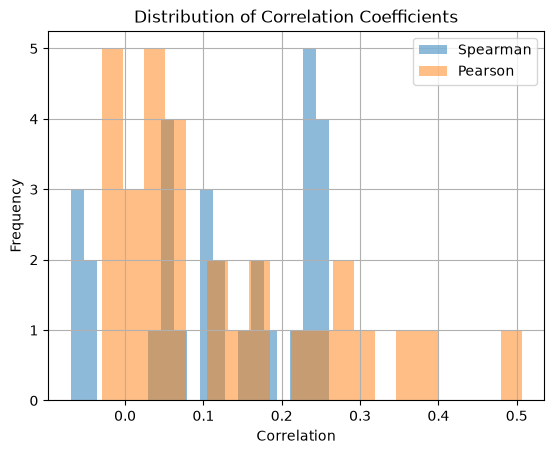

In [1130]:
result_df['sprm_point'].hist(bins=20, alpha=0.5, label='Spearman')
result_df['prsn_point'].hist(bins=20, alpha=0.5, label='Pearson')
plt.legend()
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Coefficients')
plt.show()

### Poisson

In [910]:
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

# fix structural parameters
s = 1.5
b = -1 * np.ones((global_settings['genes']))

for i in range(global_settings['repeats']):

    # sample correlation
    p = rng.choice([-0.2, 0.2, 0.4, 0.6, 0.8])

    # construct parameters
    Sigma = np.array(([
        [1, p],
        [p, 1]
    ]))
    A = s * np.linalg.cholesky(Sigma)

    # sample rate
    z = rng.normal(size=(global_settings['cells'], global_settings['genes']))
    lam = np.exp(z @ A.T + b)
    
    # sample counts
    counts[:, :, i] = rng.poisson(lam=lam).astype(np.int32)

In [ ]:
# save
#np.save("./data/lognormal-poi.npy", counts)

In [1133]:
result_df = compute_data_statistics("lognormal-poi")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,1.1607,1.1477,11.055676,15.984085,0.52853,0.406463
1,1.084,1.1415,9.511744,11.549478,0.062122,0.091195
2,1.1479,1.1963,8.749226,18.083566,0.307468,0.317066
3,1.147,1.134,11.743991,11.431844,0.605168,0.404244
4,1.1353,1.1793,9.058394,11.285152,0.05733,0.072426
5,1.0673,1.1187,9.619771,10.82861,0.048422,0.108467
6,1.112,1.1215,10.098656,8.584538,0.170477,0.189039
7,1.0988,1.1351,8.259639,12.045448,0.179503,0.195231
8,1.1479,1.1814,12.608226,14.109894,0.144743,0.18774
9,1.1046,1.1838,7.988059,10.910618,-0.037354,-0.092868


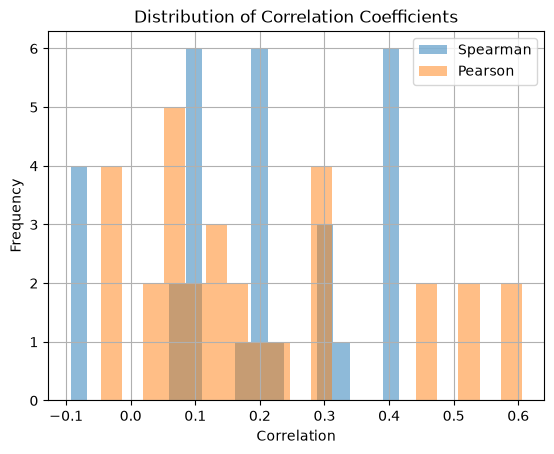

In [1134]:
result_df['sprm_point'].hist(bins=20, alpha=0.5, label='Spearman')
result_df['prsn_point'].hist(bins=20, alpha=0.5, label='Pearson')
plt.legend()
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Coefficients')
plt.show()

## Gaussian Copula

### NB

In [1111]:
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

# fix structural parameters
mu = 7.5
theta = 0.5

# convert NB parametrization (mean, dispersion) -> (#successes, p(success))
r = theta
p = theta / (theta + mu)

for i in range(global_settings['repeats']):

    # sample correlation
    p = rng.choice([-0.2, 0.2, 0.4, 0.6, 0.8])

    # construct parameters
    Sigma = np.array(([
        [1, p],
        [p, 1]
    ]))

    # sample from normal dist with correlation: one sample for each cell, across all genes
    ys = rng.multivariate_normal(np.zeros(global_settings['genes']), Sigma, size=global_settings['cells'])

    # transform to uniform marginals: prob int transform, still correlated
    us = scipy.stats.norm.cdf(ys)

    # transform (correlated) uniforms to (correlated) NB(mu, theta)
    counts[:, :, i] = scipy.stats.nbinom.ppf(us, mu, theta).astype(np.int32)

In [ ]:
# save
#np.save("./data/copula-nb.npy", counts)

In [1135]:
result_df = compute_data_statistics("copula-nb")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,7.5844,7.5064,15.179677,15.086759,0.582943,0.570747
1,7.4826,7.5006,14.804697,14.6732,0.788559,0.782457
2,7.5531,7.494,15.34698,14.859164,0.391049,0.389446
3,7.4483,7.5376,14.883927,14.907586,-0.188933,-0.190318
4,7.515,7.5159,15.024775,14.794947,0.790441,0.779739
5,7.4469,7.4582,14.69138,14.605053,0.787282,0.778704
6,7.4449,7.4995,14.909964,15.0574,0.187071,0.184554
7,7.4559,7.4609,15.023855,15.069071,0.396012,0.37677
8,7.5101,7.5257,14.981498,15.14734,0.593403,0.579787
9,7.5806,7.498,15.029904,14.850396,0.190401,0.189121


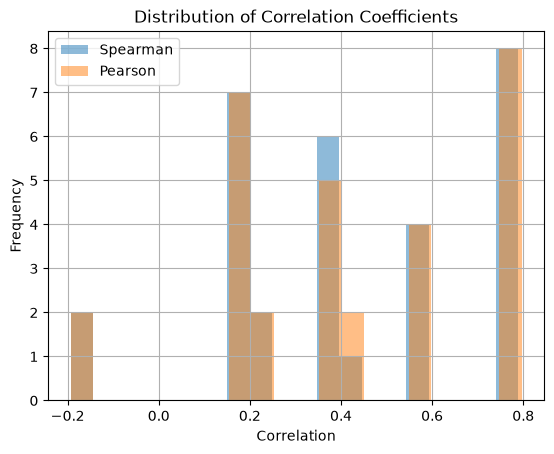

In [1136]:
result_df['sprm_point'].hist(bins=20, alpha=0.5, label='Spearman')
result_df['prsn_point'].hist(bins=20, alpha=0.5, label='Pearson')
plt.legend()
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Coefficients')
plt.show()

### Poisson

In [1115]:
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

# fix structural parameters
lam = 7.5

for i in range(global_settings['repeats']):

    # sample correlation
    p = rng.choice([-0.2, 0.2, 0.4, 0.6, 0.8])

    # construct parameters
    Sigma = np.array(([
        [1, p],
        [p, 1]
    ]))

    # sample from normal dist with correlation: one sample for each cell, across all genes
    ys = rng.multivariate_normal(np.zeros(global_settings['genes']), Sigma, size=global_settings['cells'])

    # transform to uniform marginals: prob int transform, still correlated
    us = scipy.stats.norm.cdf(ys)

    # transform (correlated) uniforms to (correlated) Poi(lam)
    counts[:, :, i] = scipy.stats.poisson.ppf(us, lam).astype(np.int32)

In [ ]:
# save
#np.save("./data/copula-poi.npy", counts)

In [1137]:
result_df = compute_data_statistics("copula-poi")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,7.4871,7.4965,7.398434,7.496188,-0.198579,-0.192442
1,7.5434,7.561,7.608116,7.537679,0.79621,0.784872
2,7.4964,7.5085,7.635787,7.492528,0.590585,0.578585
3,7.4851,7.5371,7.578778,7.450624,0.205452,0.193685
4,7.458,7.5235,7.466036,7.585848,-0.202368,-0.197503
5,7.5618,7.5591,7.584181,7.432307,0.787588,0.77803
6,7.5095,7.4946,7.40851,7.594571,-0.210746,-0.20675
7,7.4701,7.4789,7.391906,7.515755,0.785485,0.772532
8,7.5004,7.4943,7.5776,7.726168,0.792934,0.778076
9,7.4939,7.5109,7.403363,7.376481,0.587946,0.569411


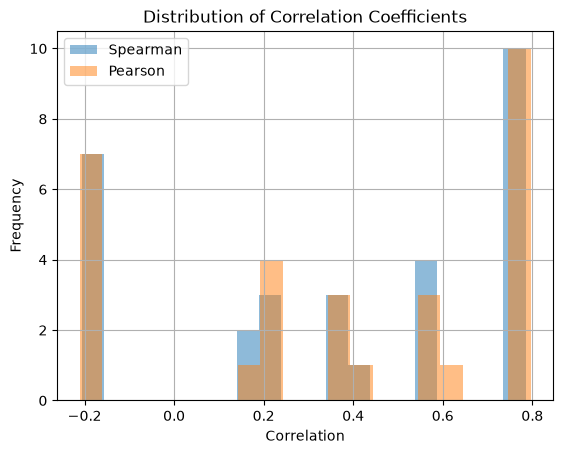

In [1138]:
result_df['sprm_point'].hist(bins=20, alpha=0.5, label='Spearman')
result_df['prsn_point'].hist(bins=20, alpha=0.5, label='Pearson')
plt.legend()
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Coefficients')
plt.show()

## Independent

### NB

In [1123]:
# fix global parameters
mu = 5
theta = 0.5

# convert NB parametrization (mean, dispersion) -> (#successes, p(success))
r = theta
p = theta / (theta + mu)

# sample genes
counts = rng.negative_binomial(r, p, size=(global_settings['cells'], global_settings['genes'], global_settings['repeats'])).astype(np.int32)

In [ ]:
# save
#np.save("./data/indep-nb.npy", counts)

In [1139]:
result_df = compute_data_statistics("indep-nb")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,4.9297,4.9755,57.855558,53.5027,-0.003414,-0.008245
1,4.9603,5.1232,53.133124,57.441422,-0.000398,-0.015743
2,5.0519,4.9318,55.515406,54.947349,-0.008364,-0.013292
3,4.9872,5.0158,51.882436,56.69715,0.011302,0.022308
4,5.075,4.9495,55.661575,55.40915,0.011112,0.005832
5,5.0421,5.0209,55.154928,55.580863,0.003604,0.011102
6,4.9653,4.9226,53.014096,52.075209,0.006403,0.011994
7,5.0576,5.1314,55.727082,60.181934,-0.009257,-0.000985
8,4.9694,5.1028,54.098864,55.080832,-0.012872,0.002247
9,4.9778,4.9545,54.011907,53.85003,0.016341,0.002083


<Axes: >

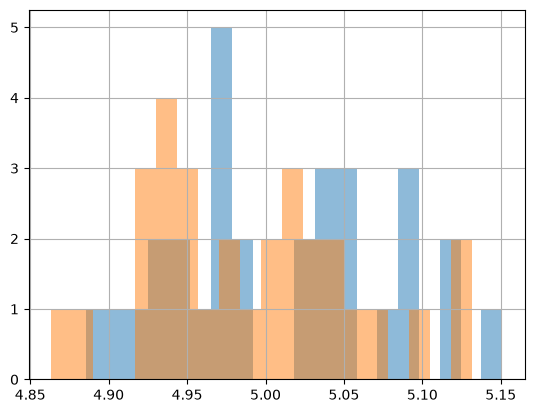

In [1140]:
result_df['mean_1_point'].hist(bins=20, alpha=0.5)
result_df['mean_2_point'].hist(bins=20, alpha=0.5)

### Poisson

In [1100]:
# fix global parameters
lam = 7.5

# sample genes
counts = rng.poisson(lam, size=(global_settings['cells'], global_settings['genes'], global_settings['repeats'])).astype(np.int32)

In [ ]:
# save
#np.save("./data/indep-poi.npy", counts)

In [1141]:
result_df = compute_data_statistics("indep-poi")
result_df

,mean_1_point,mean_2_point,vars_1_point,vars_2_point,prsn_point,sprm_point
0,7.5054,7.4801,7.556971,7.323204,-0.012265,-0.005372
1,7.5467,7.5495,7.559419,7.65535,-0.009558,-0.007519
2,7.5331,7.4848,7.430704,7.427969,0.007101,0.003775
3,7.4967,7.4969,7.485589,7.47479,-0.001579,-0.001792
4,7.4869,7.4765,7.568028,7.396248,0.004624,0.003515
5,7.496,7.483,7.576784,7.554711,0.016817,0.014747
6,7.5333,7.436,7.587691,7.529704,0.001135,-0.005483
7,7.5334,7.4575,7.463284,7.449194,-0.008547,-0.010983
8,7.4846,7.4781,7.597563,7.51312,-0.007265,-0.011779
9,7.5052,7.5035,7.517573,7.451388,-0.020866,-0.015214


In [1145]:
# important check as otherwise scVI Poisson model will error since log(0) in loss
counts = np.load("./data/indep-poi.npy")
(counts.sum(axis=1) == 0).sum()

np.int64(0)

<Axes: >

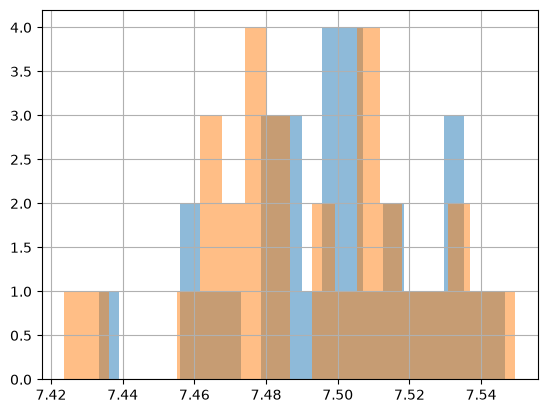

In [1146]:
result_df['mean_1_point'].hist(bins=20, alpha=0.5)
result_df['mean_2_point'].hist(bins=20, alpha=0.5)

# Filtering: 0 total count cells

In [591]:
counts = np.load(f"./data/real-data.npy")

In [596]:
# total cell counts: scVI Poisson model will error with log(0) in loss
float(100 * (counts.sum(axis=1) == 0).sum() / (counts.shape[0] * counts.shape[2]))

71.399

In [598]:
r = 0
total_count_mask = (counts[:, :, r].sum(axis=1) == 0)
counts[:, :, r][~total_count_mask]

array([[3, 1],
       [1, 0],
       [0, 1],
       ...,
       [1, 0],
       [2, 0],
       [0, 1]], shape=(653, 2), dtype=int32)

# Appendix

## G > 2 gene selection

- Aim: increase number of genes in training data to avoid l_n = 0 issues
- However:
    - still get l_n = 0 cells with G = 20 for real data
    - tricky to select real data, let alone simulate

In [ ]:
# load dataset
adata_real = ad.read_h5ad("../data/hca_subsampled_20k.h5ad")

# filter low expression genes
sc.pp.filter_genes(adata_real, min_counts=3)

# set layer
adata_real.layers["counts"] = adata_real.X.copy()

# feature selection of highly variable genes
sc.pp.highly_variable_genes(
    adata_real,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source",
)

# subset cells
adata_real = adata_real[:global_settings['cells'], :]

In [ ]:
# compute correlation matrix
Sigma = sparse_corrcoef(adata_real.X)

# compute mean expression
observed_mean = np.array(adata_real.layers['counts'].mean(axis=0)).squeeze()

# set lower triangle to nan
Sigma_lower = deepcopy(Sigma)
Sigma_lower[np.tril_indices(Sigma.shape[0], k=0)] = np.nan

# collect indices of correlation values in the bins
bin_ends = [-0.4, 0.1, 0.3, 0.5, 0.7, 1]
bin_indices = [[] for _ in range(len(bin_ends) - 1)]

for i in range(len(bin_ends) - 1):
    bin_start = bin_ends[i]
    bin_end = bin_ends[i + 1]
    indices = np.argwhere((Sigma_lower > bin_start) & (Sigma_lower <= bin_end))
    bin_indices[i] = indices
    print(f"Bin ({bin_start}, {bin_end}]: {len(indices)}")

Bin (-0.4, 0.1]: 644531
Bin (0.1, 0.3]: 61163
Bin (0.3, 0.5]: 11525
Bin (0.5, 0.7]: 1976
Bin (0.7, 1]: 205


In [ ]:
# sample gene pairs for data
counts = np.empty((global_settings['cells'], global_settings['genes'], global_settings['repeats']), dtype=np.int32)

# correlation tolerance
tau = 0.2

# mean expression tolerance
eps = 0.2

for i in range(global_settings['repeats']):

    # sample correlation bin
    sampled_bin = rng.choice(len(bin_indices), size=1)[0]

    # sample gene pair from bin
    sampled_pair_index = rng.choice(len(bin_indices[sampled_bin]), size=1)[0]
    sampled_gene_pair = bin_indices[sampled_bin][sampled_pair_index]

    # select G - 2 other genes that are reasonably uncorrelated and have similar expression level
    min_expr = min(observed_mean[sampled_gene_pair[0]], observed_mean[sampled_gene_pair[1]])
    max_expr = max(observed_mean[sampled_gene_pair[0]], observed_mean[sampled_gene_pair[1]])
    idxs = np.argwhere(
        (Sigma[sampled_gene_pair[0]] > -tau) &
        (Sigma[sampled_gene_pair[0]] < tau) &
        (Sigma[sampled_gene_pair[1]] > -tau) &
        (Sigma[sampled_gene_pair[1]] < tau) &
        (observed_mean > min_expr - eps) &
        (observed_mean < max_expr + eps)
    )
    idxs_selected = rng.choice(idxs, size=global_settings['genes'] - 2, replace=False).squeeze()

    # select all genes
    selected_genes = np.zeros((global_settings['genes']))
    selected_genes[:2] = sampled_gene_pair
    selected_genes[2:] = idxs_selected

    # get data
    adata_selected = adata_real[:, selected_genes]

    # store
    counts[:, :, i] = adata_selected.X.toarray()

In [ ]:
# important check as otherwise scVI Poisson model will error since log(0) in loss
(counts.sum(axis=1) == 0).sum()

np.int64(99060)

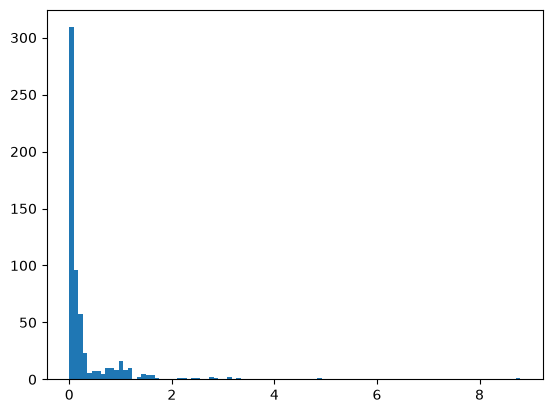

In [ ]:
plt.hist(counts.mean(axis=0).flatten(), bins=100);